In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [20]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [21]:
df.shape

(3544, 18)

In [22]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,pareena mi casa,sector 68,1.90,9228.0,3,3,3+,1.0,Under Construction,2288.0,0,1,0,0,0,0,49
1,flat,alpha corp gurgaonone,sector 84,2.28,8769.0,4,4,3+,8.0,Relatively New,2998.0,0,1,0,0,0,0,61
2,flat,m3m sierra 68,sector 68,1.10,8987.0,2,2,3,1.0,Relatively New,1150.0,0,0,0,0,0,1,127
3,house,ireo victory valley4.0 ?,sector 67,8.00,22222.0,6,7,3+,3.0,Moderately Old,3600.0,1,1,1,1,0,1,151
4,flat,kiran residency,sector 56,1.54,8324.0,3,4,3+,5.0,Old Property,1900.0,0,1,0,0,0,0,98


In [23]:
latlong = pd.read_csv('latlong.csv')

In [24]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [25]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [26]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [27]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [28]:
new_df = df.merge(latlong, on='sector')

In [29]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [30]:
group_df = new_df.groupby('sector')[['price','price_per_sqft','built_up_area','latitude','longitude']].mean()

In [31]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
sector 103,1.495000,7445.785714,1865.428571,28.4949,76.9845
...,...,...,...,...,...
sector 92,0.940303,5969.696970,1570.345253,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326
sector 95,0.480545,5602.509091,995.981818,28.4172,76.9081


In [32]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

In [33]:
new_df.to_csv('data_viz1.csv',index=False)

In [34]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [35]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sector 68 Gurgaon,flat,pareena mi casa,1.90,9227.0,2059.0,Carpet area: 2059 (191.29 sq.m.),3,3,3+,servant room,"Sector 68 Gurgaon, Gurgaon, Haryana",1.0,NaN,Under Construction,"['Sector 55-56 Metro Station', 'Airia Mall', '...","With podium, biggest balconies n biggest unit ...",[],"['Feng Shui / Vaastu Compliant', 'Security / F...","['Safety5 out of 5', 'Lifestyle4 out of 5', 'E..."
1,4 BHK Flat in Sector 84 Gurgaon,flat,alpha corp gurgaonone,2.28,8769.0,2600.0,Super Built up area 3434(319.03 sq.m.)Carpet a...,4,4,3+,servant room,"Sector 84 Gurgaon, Gurgaon, Haryana",8.0,South-East,1 to 5 Year Old,"['Delhi Public School', 'Raheja Market', 'Sapp...",This lovely 4 bhk apartment/flat in sector 84 ...,NaN,"['Intercom Facility', 'Lift(s)', 'Maintenance ...","['Green Area5 out of 5', 'Construction5 out of..."
2,2 BHK Flat in Sector 68 Gurgaon,flat,m3m sierra 68,1.10,8986.0,1224.0,Super Built up area 1224(113.71 sq.m.)Built Up...,2,2,3,not available,"T-8, Sector 68 Gurgaon, Gurgaon, Haryana",1.0,North-East,1 to 5 Year Old,"['Airia Mall', 'Sohna Road', 'Golf Course Exte...","M3m sierra 68 in sector 68, gurgaon is a ready...","['2 Wardrobe', '5 Fan', '1 Exhaust Fan', '2 Ge...","['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
3,6 Bedroom House for sale in Sector 67 Gurgaon,house,ireo victory valley4.0 ?,8.00,22222.0,3600.0,Plot area 400(334.45 sq.m.),6,7,3+,"pooja room,study room,servant room,store room","126, Sector 67 Gurgaon, Gurgaon, Haryana",3.0,North-East,5 to 10 Year Old,"['AIPL Joy Street Mall', 'Golf Course Extensio...",This villa is gated community near by reputed ...,"['6 Wardrobe', '1 Water Purifier', '1 Exhaust ...","['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment4 out of 5', 'Safety4 out of 5', ..."
4,3 BHK Flat in Sector 56 Gurgaon,flat,kiran residency,1.54,8324.0,1850.0,Super Built up area 2000(185.81 sq.m.)Built Up...,3,4,3+,servant room,"Sector 56, Sector 56 Gurgaon, Gurgaon, Haryana",5.0,South,10+ Year Old,"['Sector metro station', 'Sector metro station...","Situated in sector 56 gurgaon, kiran residency...","['3 Wardrobe', '5 Fan', '1 Exhaust Fan', '3 Ge...","['Feng Shui / Vaastu Compliant', 'Lift(s)', 'H...","['Environment4 out of 5', 'Lifestyle5 out of 5..."


In [36]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [37]:
wordcloud_df.head()

,features,sector
0,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 68
1,"['Intercom Facility', 'Lift(s)', 'Maintenance ...",sector 84
2,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 68
3,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sector 67
4,"['Feng Shui / Vaastu Compliant', 'Lift(s)', 'H...",sector 56


In [38]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [39]:
main

['Feng Shui / Vaastu Compliant',
 'Security / Fire Alarm',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage',
 'Park',
 'Visitor Parking',
 'Intercom Facility',
 'Lift(s)',
 'Maintenance Staff',
 'Swimming Pool',
 'Separate entry for servant room',
 'Park',
 'Security Personnel',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Waste Disposal',
 'Water softening plant',
 'Security / Fire Alarm',
 'Power Back-up',
 'Feng Shui / Vaastu Compliant',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'Water Storage',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'Security 

In [40]:
from wordcloud import WordCloud

In [41]:
feature_text = ' '.join(main)

In [42]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [43]:
feature_text

'Feng Shui / Vaastu Compliant Security / Fire Alarm Intercom Facility Lift(s) Maintenance Staff Water Storage Park Visitor Parking Intercom Facility Lift(s) Maintenance Staff Swimming Pool Separate entry for servant room Park Security Personnel Shopping Centre Fitness Centre / GYM Club house / Community Center Waste Disposal Water softening plant Security / Fire Alarm Power Back-up Feng Shui / Vaastu Compliant Intercom Facility Lift(s) High Ceiling Height Maintenance Staff Water Storage No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Visitor Parking Swimming Pool Park Security Personnel Natural Light Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Centrally Air Conditioned Water purifier High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storag

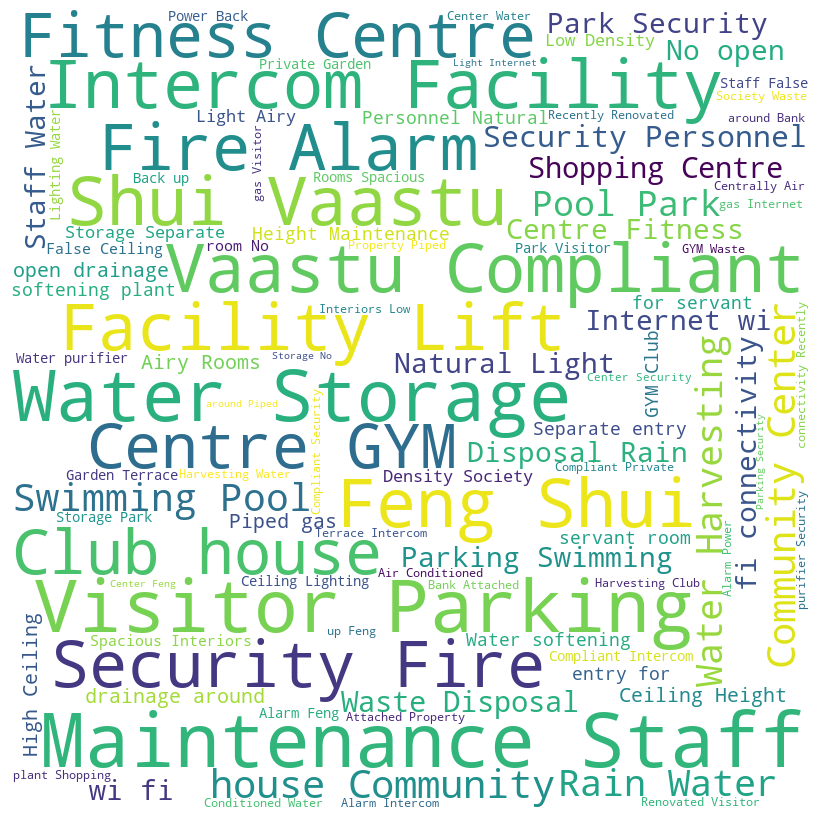

In [44]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [45]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [46]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [47]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [48]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


<Axes: xlabel='price', ylabel='Count'>

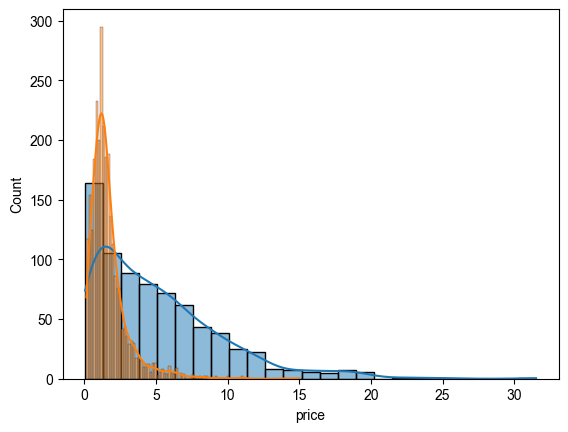

In [53]:
sns.histplot(df[df['property_type'] == 'house']['price'], kde=True, label='House')
sns.histplot(df[df['property_type'] == 'flat']['price'], kde=True, label='Flat')

In [50]:
new_df['sector'].unique().tolist().insert(0,'overall')